In [59]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
# Install all packages from
!pip install -r ../requirements.txt

In [61]:
import json, os, csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [62]:
# !!!global!!!
# plt.style.use('default')
# plt.style.use('dark_background')

Download stats analysis:

In [63]:
# Load stats/download_stats.csv and do analysis

df = pd.read_csv("../stats/download_stats.csv")
df.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7296\1618446429.py:3: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../stats/download_stats.csv")


,recid,file,bytes,start,end,duration_s,rate_Bps,success,error,expected_size,expected_checksum,computed_checksum_numeric,checksum_ok,attempts
0,80502,downloads/80502/99_175_prog_239.pdf,174717.0,1.764765e+09,1.764765e+09,0.962363,181549.996363,True,NaN,174717.0,adler32:9a26470d,2.586200e+09,True,NaN
1,80501,downloads/80501/cargo600.pdf,404470.0,1.764765e+09,1.764765e+09,1.017225,397620.874861,True,NaN,404470.0,adler32:18d0bebc,4.163335e+08,True,NaN
2,80502,downloads/80502/skelana.pdf,264402.0,1.764765e+09,1.764765e+09,0.935816,282536.223607,True,NaN,264402.0,adler32:4bac9f7a,1.269604e+09,True,NaN
3,80504,downloads/80504/dstana.pdf,489206.0,1.764765e+09,1.764765e+09,1.045380,467969.383739,True,NaN,489206.0,adler32:7304ac95,1.929686e+09,True,NaN
4,80503,downloads/80503/delgra2.0.pdf,255295.0,1.764765e+09,1.764765e+09,0.862576,295968.120697,True,NaN,255295.0,adler32:6eaeebd0,1.856957e+09,True,NaN


In [64]:
# Ensure CSV header includes the new 'attempts' column to avoid tokenizing errors

csv_path = "../stats/download_stats.csv"
expected_columns = ['recid','file','bytes','start','end','duration_s','rate_Bps',
                    'success','error','expected_size','expected_checksum',
                    'computed_checksum_numeric','checksum_ok','attempts']

if os.path.exists(csv_path):
    try:
        with open(csv_path, 'r', newline='', encoding='utf-8') as f:
            reader = csv.reader(f)
            header = next(reader, [])
    except Exception:
        header = []

    # If header differs from expected, rewrite only the header line to the expected columns.
    # This preserves existing data rows while making future reads/appends consistent.
    if header != expected_columns:
        with open(csv_path, 'r', encoding='utf-8') as f:
            lines = f.read().splitlines()
        if lines:
            lines[0] = ','.join(expected_columns)
        else:
            lines = [','.join(expected_columns)]
        with open(csv_path, 'w', encoding='utf-8', newline='') as f:
            f.write('\n'.join(lines) + '\n')

In [65]:
# print all column names
print(df.columns)

Index(['recid', 'file', 'bytes', 'start', 'end', 'duration_s', 'rate_Bps',
       'success', 'error', 'expected_size', 'expected_checksum',
       'computed_checksum_numeric', 'checksum_ok', 'attempts'],
      dtype='object')


In [66]:
# total size of downloads in num of unique recids, Gb, average speed, total downloads, total time spent downloading, errors, etc.

# Index(['recid', 'file', 'bytes', 'start', 'end', 'duration_s', 'rate_Bps',
#       'success', 'error', 'expected_size', 'expected_checksum',
#       'computed_checksum_numeric', 'checksum_ok'],
#      dtype='object')

recids = df['recid'].nunique()
total_size = df['bytes'].sum()
average_download_speed = df['rate_Bps'].mean()
average_speed = total_size / (df['end'].max() - df['start'].min())
total_downloads = len(df)
total_time_spent = df['duration_s'].sum()
total_errors = df['success'].value_counts().get(False, 0)

print(f"Downloaded unique recids: {recids}")
print(f"Total size of downloads: {total_size / (1024**3)} GB")
print(f"Average download speed: {average_download_speed / (1024**2)} MBps")
print(f"Average speed (total size / total time): {average_speed / (1024**2)} MBps")
print(f"Total downloads: {total_downloads}")
print(f"Total time spent downloading: {total_time_spent} seconds")
print(f"Total errors: {total_errors}")

Downloaded unique recids: 12711
Total size of downloads: 34507.82504795678 GB
Average download speed: 48.53262939253684 MBps
Average speed (total size / total time): 26.05131060932359 MBps
Total downloads: 455841
Total time spent downloading: 883034.7257785797 seconds
Total errors: 4559


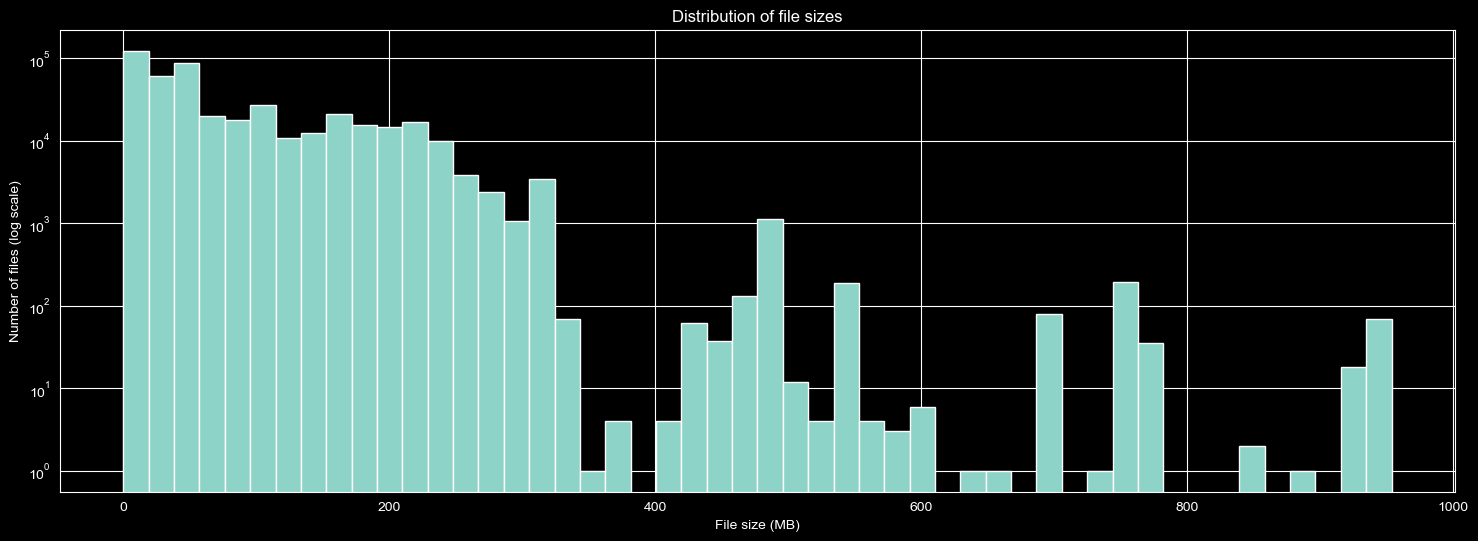

In [67]:
# Plot histogram of download sizes, x logarithmic, in MB, with 50 bins, label axes, title, etc.
plt.figure(figsize=(18, 6))
plt.hist(df['bytes'] / (1024**2), bins=50, log=True)
plt.xlabel('File size (MB)')
plt.ylabel('Number of files (log scale)')
plt.title('Distribution of file sizes')
plt.savefig('../figs/download_size_distribution.png', bbox_inches='tight')
plt.show()

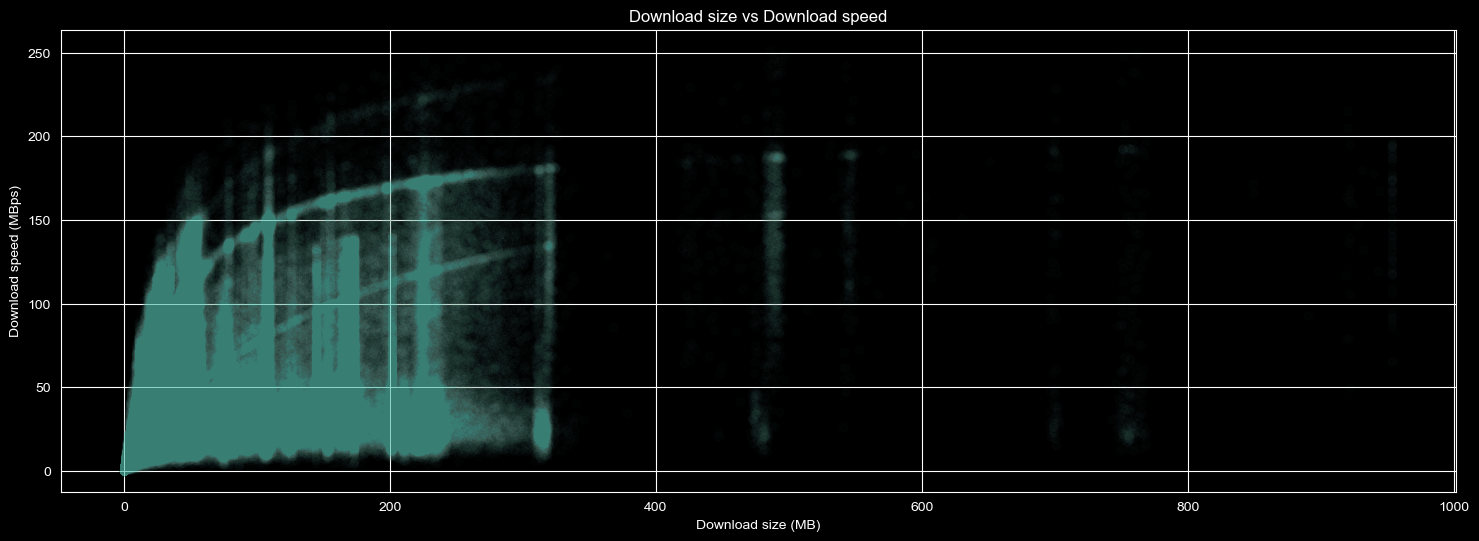

In [68]:
# Correlation between download size and download speed
plt.figure(figsize=(18, 6))
plt.scatter(df['bytes'] / (1024**2), df['rate_Bps'] / (1024**2), alpha=0.01)
plt.xlabel('Download size (MB)')
plt.ylabel('Download speed (MBps)')
plt.title('Download size vs Download speed')
plt.savefig('../figs/download_size_vs_speed.png', bbox_inches='tight')
plt.show()

In [69]:
# print ordered bins of 50 from distribution of number of files per recid, skip empty bins
files_per_recid = df['recid'].value_counts()

bins = pd.cut(files_per_recid, bins=range(0, files_per_recid.max() + 50, 20))
binned_counts = files_per_recid.groupby(bins).size()
binned_countsf = binned_counts[binned_counts.values != 0]
print(binned_countsf)

count
(0, 20]           11647
(20, 40]            323
(40, 60]            143
(60, 80]             77
(80, 100]            94
                  ...  
(9880, 9900]          1
(9900, 9920]          1
(10340, 10360]        1
(10560, 10580]        1
(14180, 14200]        1
Name: count, Length: 79, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7296\3209077100.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_counts = files_per_recid.groupby(bins).size()


In [70]:
# logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
# print(logbins)

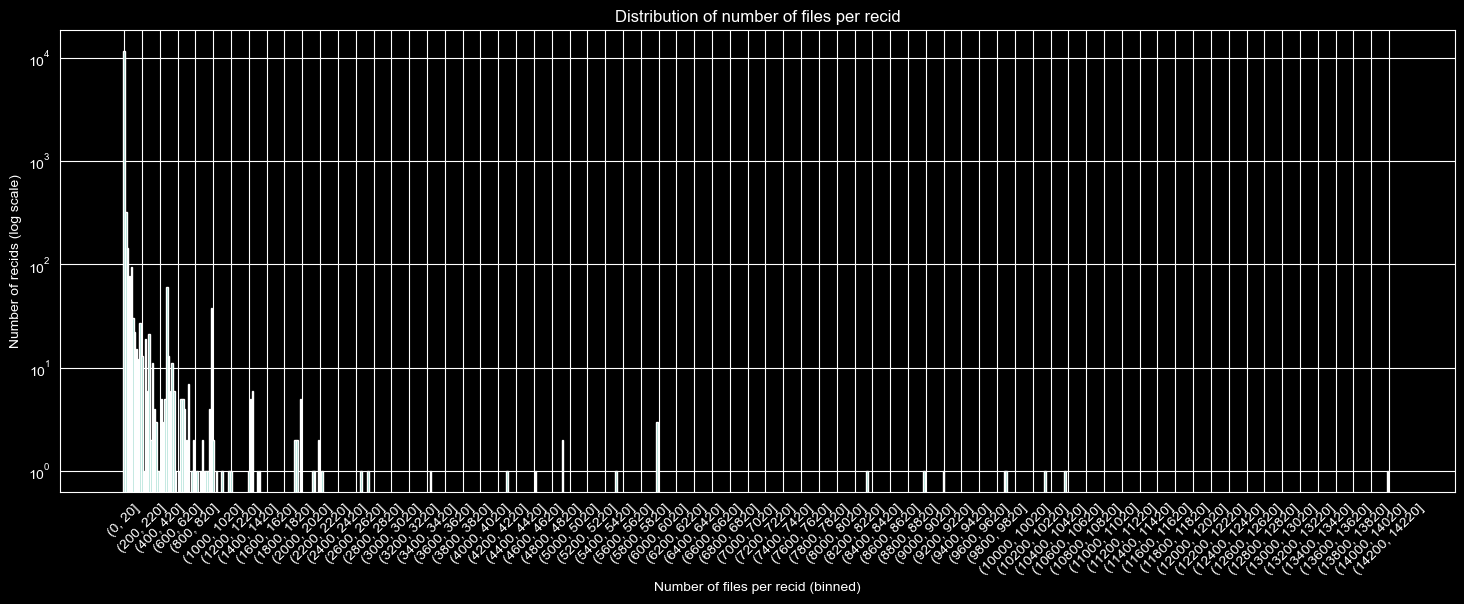

In [71]:
# plot the bins on a log scale, wide graph, modify tics - print every tenth label
plt.figure(figsize=(18, 6))
plt.bar(binned_counts.index.astype(str), binned_counts.values)
plt.yscale('log')
plt.xlabel('Number of files per recid (binned)')
plt.ylabel('Number of recids (log scale)')
plt.title('Distribution of number of files per recid')
plt.xticks(rotation=45)
plt.gca().set_xticks(plt.gca().get_xticks()[::10])
plt.savefig('../figs/files_per_recid_distribution.png', bbox_inches='tight')
plt.show()

<Figure size 1800x600 with 0 Axes>

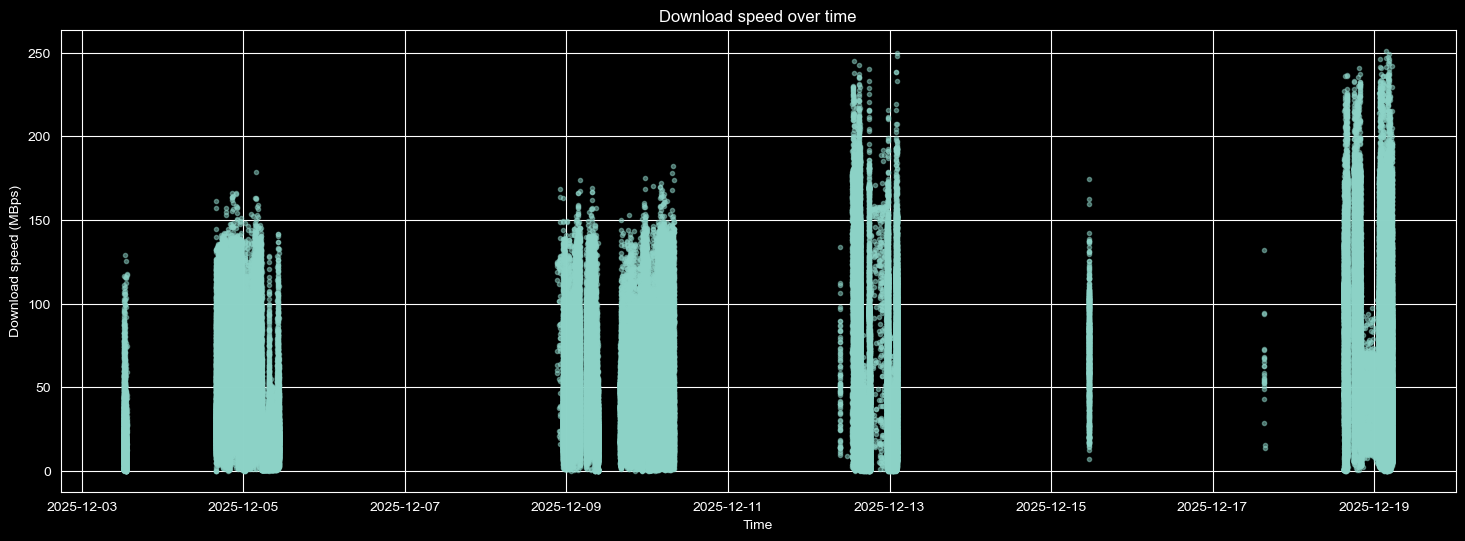

In [72]:
# plot download speed over time
plt.figure(figsize=(18, 6))
df['start_time'] = pd.to_datetime(df['start'], unit='s')
df = df.sort_values(by='start_time')
plt.figure(figsize=(18, 6))
plt.plot(df['start_time'], df['rate_Bps'] / (1024**2), marker='.', linestyle='None', alpha=0.5)
plt.xlabel('Time')
plt.ylabel('Download speed (MBps)')
plt.title('Download speed over time')
plt.show()

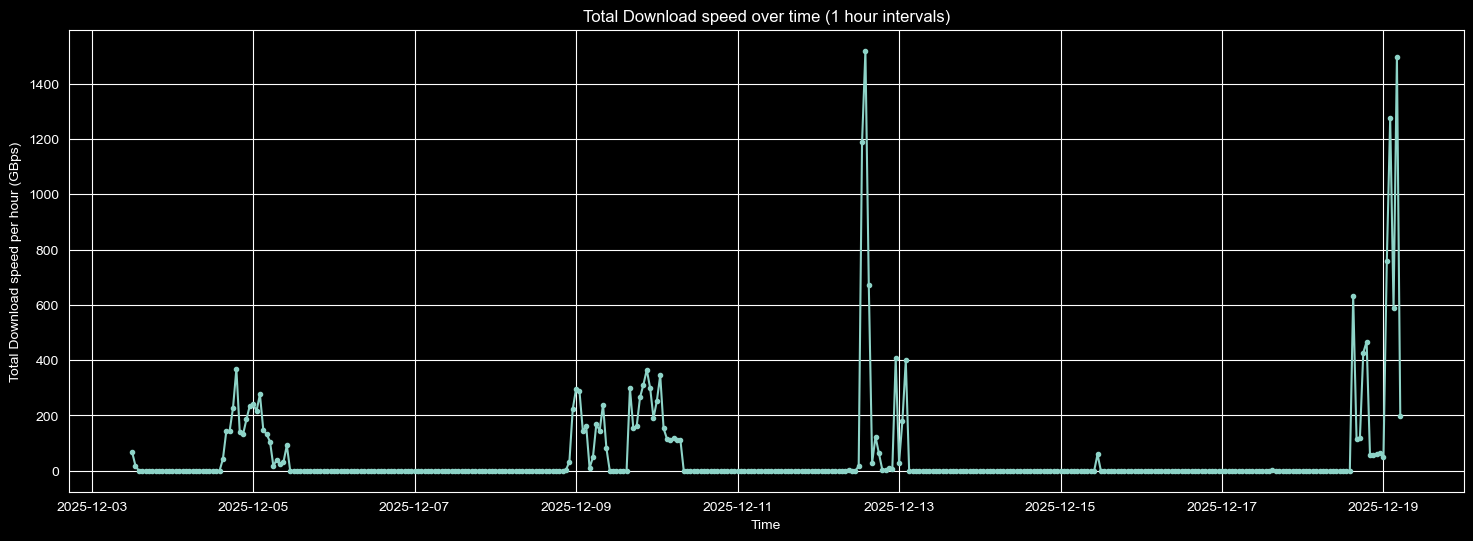

Average total download speed per hour: 224.51797046889249 GBps
Top 5 hours by total download speed (GBps):
2025-12-12 14:00:00: 1519.2212023114878 GBps
2025-12-19 04:00:00: 1496.4559739298056 GBps
2025-12-19 02:00:00: 1275.5630911104527 GBps
2025-12-12 13:00:00: 1188.5767835616796 GBps
2025-12-19 01:00:00: 758.1837137952458 GBps


In [73]:
# plot sum of download speed over one hour intervals
df['start_time_s'] = pd.to_datetime(df['start'], unit='s')
df2 = df.sort_values(by='start_time_s')
df2.set_index('start_time_s', inplace=True)
resampled = df2['rate_Bps'].resample('1h').sum()
# resampled = resampled[resampled > 0]
plt.figure(figsize=(18, 6))
plt.plot(resampled.index, resampled.values / (1024**3), marker='.', linestyle='-')
plt.xlabel('Time')
plt.ylabel('Total Download speed per hour (GBps)')
plt.title('Total Download speed over time (1 hour intervals)')
plt.savefig('../figs/total_download_speed_per_hour.png', bbox_inches='tight')
plt.show()

# print info about top 5 hours with highest total download speed
top_hours = resampled.sort_values(ascending=False).head(5)
print(f"Average total download speed per hour: {resampled[resampled > 0].mean() / (1024**3)} GBps")
print("Top 5 hours by total download speed (GBps):")
for time, speed in top_hours.items():
    print(f"{time}: {speed / (1024**3)} GBps")

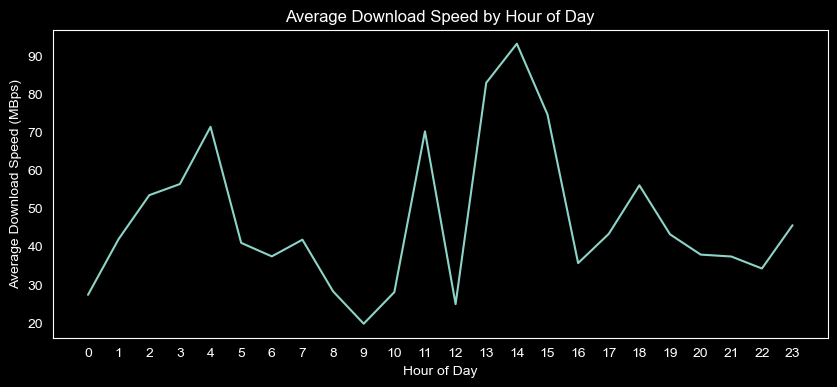

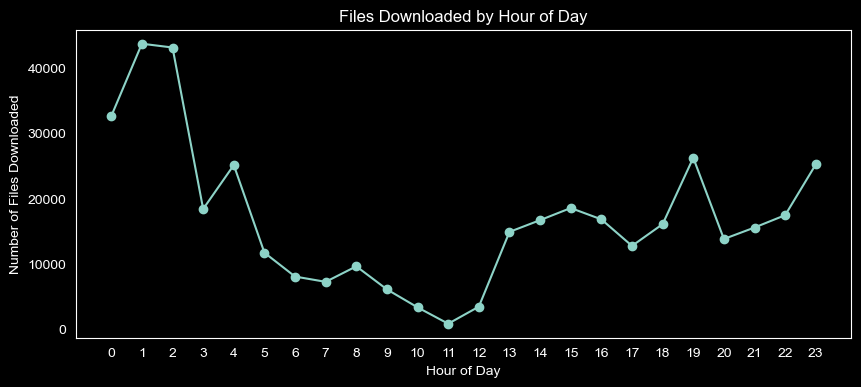

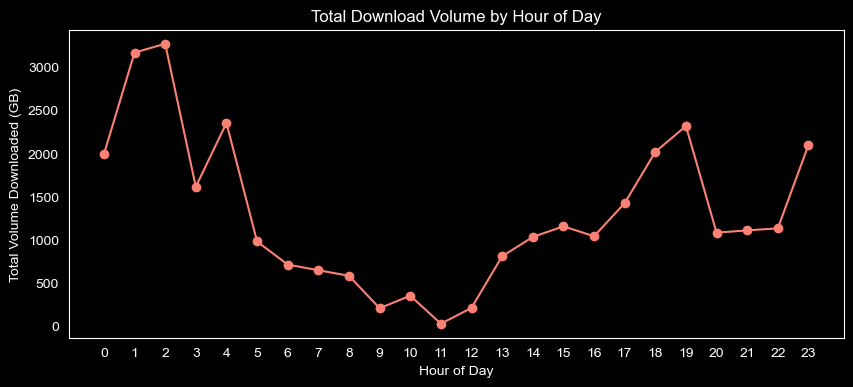

Top 3 hours by total downloaded volume (GB):
Hour 2.0: 3272.294 GB, files: 43078
Hour 1.0: 3169.026 GB, files: 43657
Hour 4.0: 2353.295 GB, files: 25114
Bottom 3 hours by total downloaded volume (GB):
Hour 11.0: 24.090 GB, files: 864
Hour 9.0: 203.591 GB, files: 6108
Hour 12.0: 207.726 GB, files: 3472


In [74]:
df['start_time'] = pd.to_datetime(df['start'], unit='s')
df['hour'] = df['start_time'].dt.hour
speed_by_hour = df.groupby('hour')['rate_Bps'].mean()
plt.figure(figsize=(10, 4))
plt.plot(speed_by_hour.index, speed_by_hour.values / (1024**2))
plt.xlabel('Hour of Day')
plt.ylabel('Average Download Speed (MBps)')
plt.title('Average Download Speed by Hour of Day')
plt.xticks(range(0, 24))
plt.grid()
plt.show()

# New: weight of data per hour -> number of files and total volume
files_by_hour = df.groupby('hour').size()                     # number of files downloaded in each hour
total_volume_by_hour = df.groupby('hour')['bytes'].sum()      # total bytes downloaded in each hour

# Plot number of files per hour
plt.figure(figsize=(10, 4))
plt.plot(files_by_hour.index, files_by_hour.values, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Files Downloaded')
plt.title('Files Downloaded by Hour of Day')
plt.xticks(range(0, 24))
plt.grid()
plt.show()

# Plot total volume per hour (GB)
plt.figure(figsize=(10, 4))
plt.plot(total_volume_by_hour.index, total_volume_by_hour.values / (1024**3), marker='o', color='C3')
plt.xlabel('Hour of Day')
plt.ylabel('Total Volume Downloaded (GB)')
plt.title('Total Download Volume by Hour of Day')
plt.xticks(range(0, 24))
plt.grid()
plt.show()

# Short textual summary: top 3 hours by volume
top_hours = total_volume_by_hour.sort_values(ascending=False).head(3)
print("Top 3 hours by total downloaded volume (GB):")
for hour, bytes_ in top_hours.items():
    print(f"Hour {hour}: {bytes_ / (1024**3):.3f} GB, files: {files_by_hour.get(hour,0)}")

# bottom 3 hours by volume
bottom_hours = total_volume_by_hour[total_volume_by_hour > 0].sort_values().head(3)
print("Bottom 3 hours by total downloaded volume (GB):")
for hour, bytes_ in bottom_hours.items():
    print(f"Hour {hour}: {bytes_ / (1024**3):.3f} GB, files: {files_by_hour.get(hour,0)}")